In [1]:
import importlib.util, subprocess, sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    # Colab already ships torch, torchvision, sklearn, matplotlib and tqdm.
    # Only transformers needs upgrading -- the preinstalled version is sometimes
    # too old to accept attn_implementation, which this notebook depends on.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "--upgrade", "transformers"], check=False)
else:
    # Local: uncomment and run once, then restart the kernel.
    # !pip install torch torchvision transformers pillow numpy matplotlib scikit-learn tqdm ipykernel
    pass

print("Colab" if IN_COLAB else "local environment")

Colab


In [2]:
import os, time, glob, json

import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel, ViTForImageClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

%matplotlib inline

In [3]:
MODEL_NAME = "google/vit-base-patch16-224"

FORCE_CUDA = False   # set True to use a small GPU anyway (expect OOM under ~4 GB)

# ---- device selection -----------------------------------------------------
gpu_gb = 0.0
if torch.cuda.is_available():
    gpu_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3

use_cuda = torch.cuda.is_available() and (gpu_gb >= 4.0 or FORCE_CUDA)
DEVICE = torch.device("cuda" if use_cuda else "cpu")

# ---- sizes scaled to the hardware -----------------------------------------
if DEVICE.type == "cuda":
    BATCH_SIZE = 64 if gpu_gb >= 8 else 16
    N_TRAIN, N_TEST = 5000, 2000   # feature extraction sizes
    N_EVAL = 1000                  # masking eval size
else:
    BATCH_SIZE = 16
    N_TRAIN, N_TEST = 2000, 1000
    N_EVAL = 300
    torch.set_num_threads(os.cpu_count() or 4)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

ROOT = os.getcwd()
OUT_DIR   = os.path.join(ROOT, "outputs")
CACHE_DIR = os.path.join(ROOT, "cache")
IMG_DIR   = os.path.join(ROOT, "data", "images")
DATA_ROOT = os.path.join(ROOT, "data")
for _d in (OUT_DIR, CACHE_DIR, IMG_DIR):
    os.makedirs(_d, exist_ok=True)

# Dataset for the linear probes and the masking experiment.
# "cifar10" -> 170 MB download, 32x32 upsampled to 224 (lossy but fine for probing)
# "stl10"   -> ~2.5 GB download, 96x96 (sharper, slower)
DATASET = "cifar10"

print(f"environment : {'Colab' if IN_COLAB else 'local'}")
if torch.cuda.is_available():
    print(f"gpu detected: {torch.cuda.get_device_name(0)}  ({gpu_gb:.1f} GB)")
    if not use_cuda:
        print("              -> under 4 GB, using CPU instead (set FORCE_CUDA=True to override)")
else:
    print("gpu detected: none")
print(f"device      : {DEVICE}")
print(f"batch size  : {BATCH_SIZE}")
print(f"sizes       : N_TRAIN={N_TRAIN}, N_TEST={N_TEST}, N_EVAL={N_EVAL}")
print(f"working dir : {ROOT}")
if DEVICE.type == "cpu":
    print(f"torch threads: {torch.get_num_threads()}")

environment : Colab
gpu detected: Tesla T4  (14.6 GB)
device      : cuda
batch size  : 64
sizes       : N_TRAIN=5000, N_TEST=2000, N_EVAL=1000
working dir : /content


In [4]:
existing = [f for f in os.listdir(IMG_DIR) if not f.startswith(".")]

if IN_COLAB and not existing:
    from google.colab import files
    print("Select 1-3 photographs to upload...")
    uploaded = files.upload()
    for name in uploaded:
        os.replace(name, os.path.join(IMG_DIR, name))

found = [f for f in os.listdir(IMG_DIR) if not f.startswith(".")]
if found:
    print(f"{len(found)} image(s) in {IMG_DIR}:")
    for f in found:
        print("  -", f)
else:
    print(f"No images in {IMG_DIR}")
    print("Sections 2, 3, 4 and part of 7 will fail until you add some.")
    print("Sections 5 and 6 (CIFAR-10 only) will still run.")

Select 1-3 photographs to upload...


Saving 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49276.jpg to 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49276.jpg
Saving 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49279.jpg to 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49279.jpg
Saving 1000311708.jpg to 1000311708.jpg
3 image(s) in /content/data/images:
  - 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49276.jpg
  - 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49279.jpg
  - 1000311708.jpg


In [5]:
def _from_pretrained_eager(cls, name, **kw):
    try:
        return cls.from_pretrained(name, attn_implementation="eager", **kw)
    except TypeError:
        # transformers < 4.36 has no attn_implementation kwarg and is eager anyway
        return cls.from_pretrained(name, **kw)


def load_processor():
    """The 'feature extractor': resize to 224x224, rescale to [0,1], normalise."""
    return AutoImageProcessor.from_pretrained(MODEL_NAME)


def load_classifier():
    """ViT with the ImageNet-1k head (1000 classes)."""
    return _from_pretrained_eager(ViTForImageClassification, MODEL_NAME).to(DEVICE).eval()


def load_backbone():
    """ViT encoder without the head.

    last_hidden_state has shape (B, 197, 768):
        index 0      -> [CLS] token
        index 1..196 -> the 14x14 = 196 patch tokens
    ViTModel already applies a final LayerNorm, so these are the features you want
    for linear probing.
    """
    return _from_pretrained_eager(AutoModel, MODEL_NAME).to(DEVICE).eval()


def grid_size(model):
    """Patches per side: 224 // 16 = 14."""
    cfg = model.config
    img   = cfg.image_size if isinstance(cfg.image_size, int) else cfg.image_size[0]
    patch = cfg.patch_size if isinstance(cfg.patch_size, int) else cfg.patch_size[0]
    return img // patch

In [6]:
def mask_patches(pixel_values, patch_indices, grid, patch_size=16, value=0.0):
    """Zero out the given patches of an already-normalised pixel tensor.

    value = 0.0 in *normalised* space == the per-channel dataset mean in pixel
    space, i.e. a neutral grey. This is deliberate: filling with black (about
    -2.1 after normalisation) would be an out-of-distribution input and would
    confound the experiment.
    """
    x = pixel_values.clone()
    for p in patch_indices:
        r, c = divmod(int(p), grid)
        x[:, :, r*patch_size:(r+1)*patch_size, c*patch_size:(c+1)*patch_size] = value
    return x


def _dist_from_centre(grid):
    coords = np.stack(np.meshgrid(np.arange(grid), np.arange(grid), indexing="ij"), -1)
    centre = (grid - 1) / 2.0
    return np.linalg.norm(coords - centre, axis=-1).reshape(-1)


def random_patch_indices(n_mask, grid, rng):
    """Uniformly scattered patches."""
    return rng.choice(grid * grid, size=n_mask, replace=False)


def center_patch_indices(n_mask, grid):
    """The n_mask patches closest to the centre (structured occlusion)."""
    return np.argsort(_dist_from_centre(grid))[:n_mask]


def border_patch_indices(n_mask, grid):
    """The n_mask patches furthest from the centre (the complementary control)."""
    return np.argsort(-_dist_from_centre(grid))[:n_mask]


def denormalize(pixel_values, processor):
    """Undo processor normalisation so a tensor can be shown with imshow."""
    mean = torch.tensor(processor.image_mean).view(1, 3, 1, 1)
    std  = torch.tensor(processor.image_std).view(1, 3, 1, 1)
    return (pixel_values.cpu() * std + mean).clamp(0, 1)


def collect_images(k=3):
    paths = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
        paths.extend(glob.glob(os.path.join(IMG_DIR, ext)))
    paths = sorted(set(paths))[:k]
    if not paths:
        raise FileNotFoundError(
            f"No images found in {IMG_DIR}\n"
            "Drop 1-3 photographs there and re-run this cell."
        )
    return paths

In [7]:
# Load the image processor and ViT classifier
processor = load_processor()
classifier = load_classifier()
GRID = grid_size(classifier)

print("Processor loaded")
print("Classifier loaded")
print("Device:", DEVICE)
print("Grid size:", GRID)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Processor loaded
Classifier loaded
Device: cuda
Grid size: 14


# Task 2.1:

In [8]:
image_paths = collect_images()
records = []

for path in image_paths:
    image = Image.open(path).convert("RGB")

    # processor: resize -> rescale -> normalise; returns (1, 3, 224, 224)
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    t0 = time.time()
    with torch.no_grad():
        logits = classifier(**inputs).logits
    dt = time.time() - t0

    probs = logits.softmax(-1)[0]
    top5 = torch.topk(probs, k=5)

    print(f"\n--- {os.path.basename(path)}  (original size {image.size}, {dt:.2f}s) ---")
    for rank, (p, idx) in enumerate(zip(top5.values, top5.indices), start=1):
        label = classifier.config.id2label[int(idx)]
        marker = "  <-- top-1" if rank == 1 else ""
        print(f"  {rank}. {label:<45s} {p.item():.4f}{marker}")

    records.append({
        "image": os.path.basename(path),
        "top1_label": classifier.config.id2label[int(top5.indices[0])],
        "top1_index": int(top5.indices[0]),
        "top1_prob": float(top5.values[0]),
        "top5": [{"label": classifier.config.id2label[int(i)], "prob": float(p)}
                 for p, i in zip(top5.values, top5.indices)],
    })

with open(os.path.join(OUT_DIR, "task2_1_predictions.json"), "w") as f:
    json.dump(records, f, indent=2)
print("\nsaved -> outputs/task2_1_predictions.json")


--- 1000311708.jpg  (original size (2252, 2250), 0.72s) ---
  1. coffee mug                                    0.6148  <-- top-1
  2. cup                                           0.3787
  3. pitcher, ewer                                 0.0014
  4. espresso                                      0.0008
  5. water jug                                     0.0007

--- 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49276.jpg  (original size (4000, 2252), 0.01s) ---
  1. wall clock                                    0.8347  <-- top-1
  2. analog clock                                  0.1588
  3. barometer                                     0.0044
  4. stopwatch, stop watch                         0.0006
  5. digital clock                                 0.0005

--- 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49279.jpg  (original size (4000, 2252), 0.01s) ---
  1. running shoe                                  0.8832  <-- top-1
  2. Loafer                                        0.0463
  3. shoe sh

# Task 2.2:

In [9]:
def cls_attention_last_layer(attentions, head=None):
    """Extract the [CLS] -> patches attention vector from the final layer.

    Returns a (196,) numpy array.
    """
    last = attentions[-1]           # (B, H, 197, 197)
    cls_row = last[0, :, 0, 1:]     # (H, 196) -- row 0, drop CLS->CLS self-attention
    vec = cls_row.mean(0) if head is None else cls_row[head]
    return vec.detach().cpu().numpy()


def attention_rollout(attentions, discard_ratio=0.0):
    """Abnar & Zuidema (2020) attention rollout.

    Raw last-layer attention only tells you where the final block looked. But every
    patch token at layer 12 is itself a mixture of tokens from layer 11, and so on.
    Rollout accounts for that by (a) adding the identity to model the residual
    stream, (b) row-normalising, and (c) multiplying the layer matrices together.
    The result approximates attribution from [CLS] at the output back to the *input*
    patches, which is usually far more object-shaped than raw final-layer attention.
    """
    result = None
    for attn in attentions:
        a = attn[0].mean(0).clone()                  # (197, 197), head-averaged

        if discard_ratio > 0:
            flat = a.flatten()
            k = int(flat.numel() * discard_ratio)
            if k > 0:
                _, idx = flat.topk(k, largest=False)
                flat[idx] = 0.0
                a = flat.view_as(a)

        a = a + torch.eye(a.size(-1), device=a.device)   # residual connection
        a = a / a.sum(dim=-1, keepdim=True)              # re-normalise rows
        result = a if result is None else a @ result

    return result[0, 1:].detach().cpu().numpy()          # CLS row, patches only


def to_heatmap(vec, grid, size=224):
    """Reshape a length-196 vector to 14x14 and upsample to image resolution."""
    hm = torch.tensor(np.asarray(vec), dtype=torch.float32).reshape(1, 1, grid, grid)
    hm = F.interpolate(hm, size=(size, size), mode="bilinear", align_corners=False)
    hm = hm[0, 0].numpy()
    return (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)   # min-max for display

In [10]:
def overlay_figure(image224, maps, titles, path, suptitle):
    n = len(maps) + 1
    fig, axes = plt.subplots(1, n, figsize=(3.1*n, 3.6))
    axes = np.atleast_1d(axes)

    axes[0].imshow(image224); axes[0].set_title("input (224x224)", fontsize=9); axes[0].axis("off")
    for ax, hm, title in zip(axes[1:], maps, titles):
        ax.imshow(image224)
        ax.imshow(hm, cmap="jet", alpha=0.5)    # semi-transparent heat overlay
        ax.set_title(title, fontsize=9); ax.axis("off")

    fig.suptitle(suptitle, fontsize=11)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def per_head_figure(image224, attentions, grid, path, suptitle):
    n_heads = attentions[-1].shape[1]
    cols = 6
    rows = int(np.ceil(n_heads / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.1*cols, 2.3*rows))
    axes = np.atleast_1d(axes).ravel()

    for h in range(n_heads):
        hm = to_heatmap(cls_attention_last_layer(attentions, head=h), grid)
        axes[h].imshow(image224)
        axes[h].imshow(hm, cmap="jet", alpha=0.5)
        axes[h].set_title(f"head {h}", fontsize=8); axes[h].axis("off")
    for ax in axes[n_heads:]:
        ax.axis("off")

    fig.suptitle(suptitle, fontsize=11)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


--- 1000311708 ---
num layers          : 12
per-layer attn shape: (1, 12, 197, 197)  (batch, heads, seq_len, seq_len)
top-1               : coffee mug


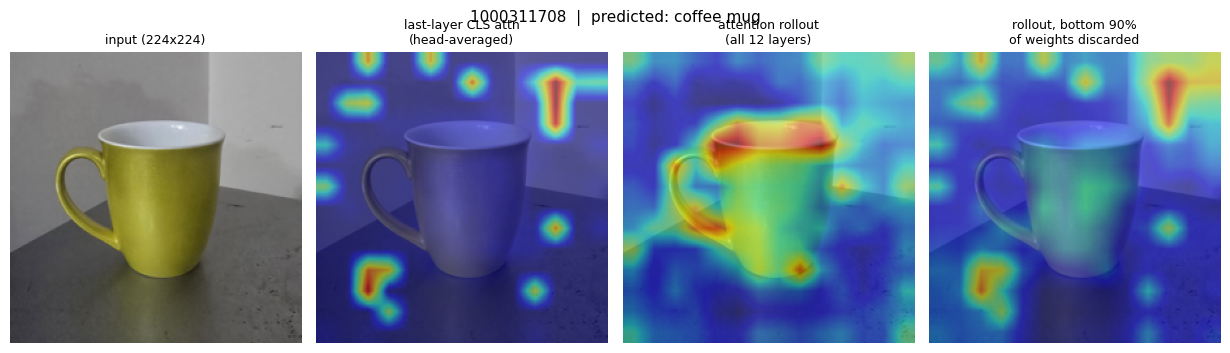

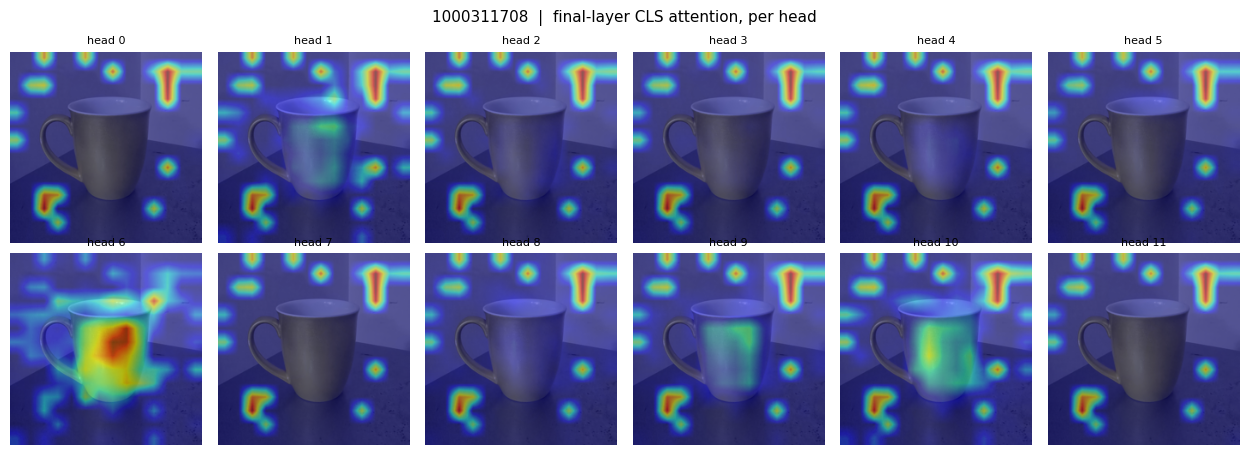


--- 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49276 ---
num layers          : 12
per-layer attn shape: (1, 12, 197, 197)  (batch, heads, seq_len, seq_len)
top-1               : wall clock


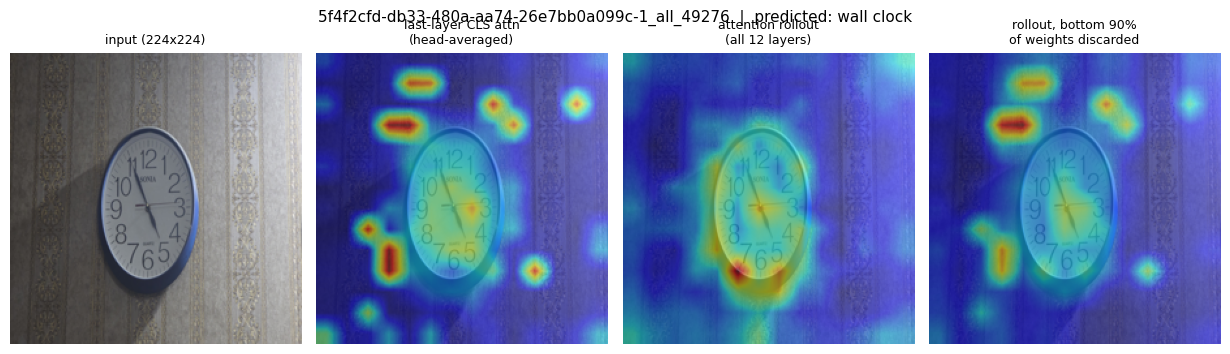

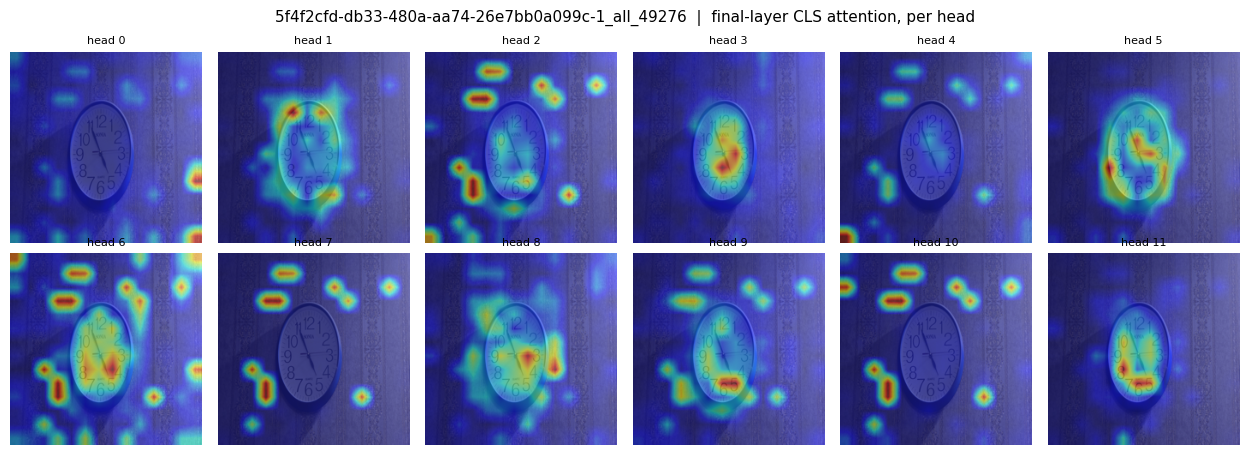


--- 5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49279 ---
num layers          : 12
per-layer attn shape: (1, 12, 197, 197)  (batch, heads, seq_len, seq_len)
top-1               : running shoe


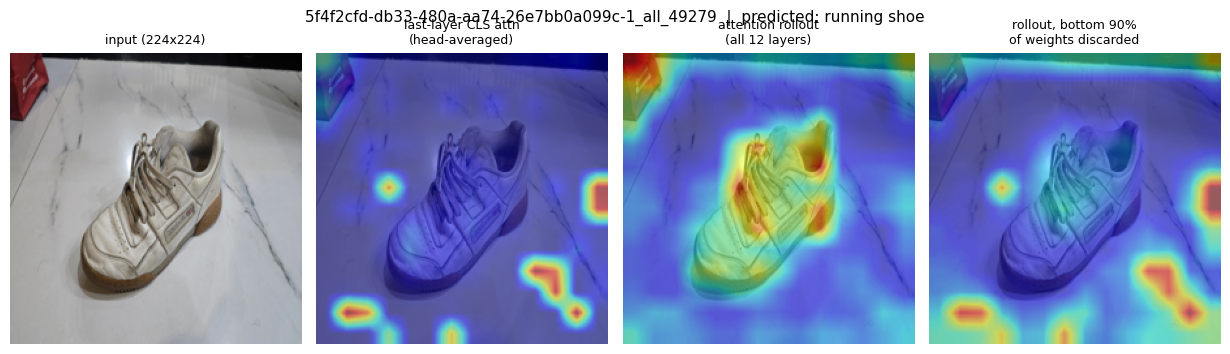

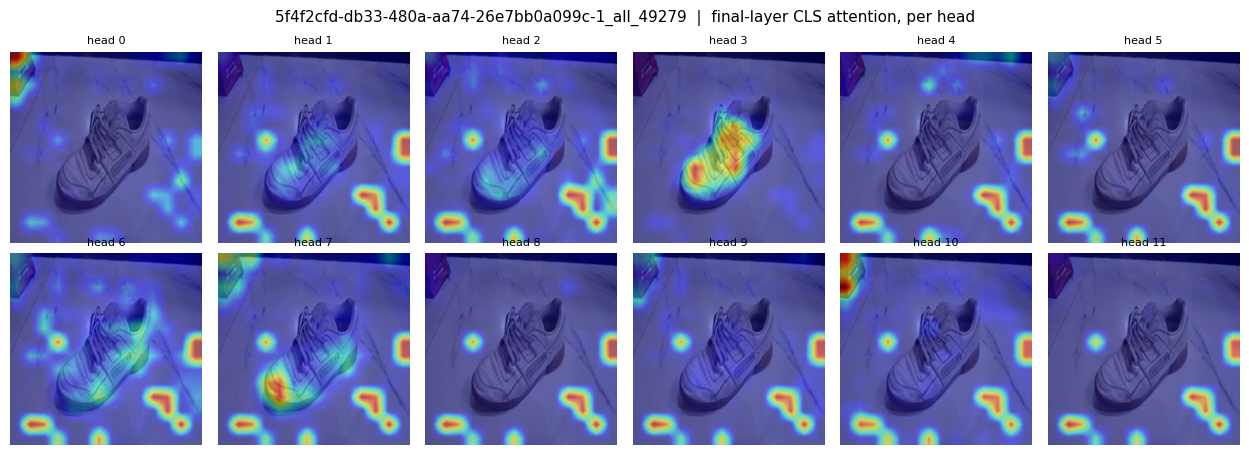

In [11]:
attention_cache = {}   # reused in section 4

for path in image_paths:
    stem = os.path.splitext(os.path.basename(path))[0]
    image = Image.open(path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        out = classifier(**inputs, output_attentions=True)

    attentions = out.attentions
    if attentions is None or attentions[0] is None:
        raise RuntimeError(
            "attentions came back None -- the SDPA kernel is in use.\n"
            "Check that attn_implementation='eager' was accepted when loading."
        )
    attention_cache[stem] = attentions

    pred  = int(out.logits.argmax(-1))
    label = classifier.config.id2label[pred]

    print(f"\n--- {stem} ---")
    print(f"num layers          : {len(attentions)}")
    print(f"per-layer attn shape: {tuple(attentions[-1].shape)}  (batch, heads, seq_len, seq_len)")
    print(f"top-1               : {label}")

    image224 = image.resize((224, 224))
    raw    = to_heatmap(cls_attention_last_layer(attentions), GRID)
    roll   = to_heatmap(attention_rollout(attentions), GRID)
    roll_d = to_heatmap(attention_rollout(attentions, discard_ratio=0.9), GRID)

    overlay_figure(
        image224, [raw, roll, roll_d],
        ["last-layer CLS attn\n(head-averaged)",
         "attention rollout\n(all 12 layers)",
         "rollout, bottom 90%\nof weights discarded"],
        os.path.join(OUT_DIR, f"task2_2_attention_{stem}.png"),
        f"{stem}  |  predicted: {label}",
    )

    per_head_figure(
        image224, attentions, GRID,
        os.path.join(OUT_DIR, f"task2_3_heads_{stem}.png"),
        f"{stem}  |  final-layer CLS attention, per head",
    )

Task 2.3

In [12]:
def patch_distance_matrix(grid):
    """(196, 196) euclidean distances between patch centres, in patch units."""
    coords = np.stack(np.meshgrid(np.arange(grid), np.arange(grid), indexing="ij"),
                      -1).reshape(-1, 2).astype(np.float32)
    return np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)


def head_stats(attentions, dist):
    """Returns (entropy, mean_distance), each of shape (num_layers, num_heads)."""
    L, H = len(attentions), attentions[0].shape[1]
    ent = np.zeros((L, H)); mad = np.zeros((L, H))

    for l, attn in enumerate(attentions):
        a = attn[0].detach().cpu().numpy()                  # (H, 197, 197)

        p = np.clip(a, 1e-12, 1.0)                          # entropy over all 197 tokens
        ent[l] = (-(p * np.log(p)).sum(-1)).mean(-1)

        pp = a[:, 1:, 1:]                                   # patch->patch only
        pp = pp / np.clip(pp.sum(-1, keepdims=True), 1e-12, None)
        mad[l] = (pp * dist[None]).sum(-1).mean(-1)

    return ent, mad

In [13]:
dist = patch_distance_matrix(GRID)

all_ent, all_mad = [], []
for stem, attentions in attention_cache.items():
    e, m = head_stats(attentions, dist)
    all_ent.append(e); all_mad.append(m)

ent = np.mean(all_ent, axis=0)      # (L, H), averaged over the images
mad = np.mean(all_mad, axis=0)
L, H = ent.shape

np.savez(os.path.join(OUT_DIR, "task2_3_head_stats.npz"), entropy=ent, mad=mad)

print(f"max possible entropy (seq_len=197) : {np.log(197):.2f} nats")
print(f"max possible patch distance ({GRID}x{GRID}): {np.sqrt(2)*(GRID-1):.2f} patches\n")
print("layer | entropy: min / mean / max | mean-attn-dist: min / mean / max")
for l in range(L):
    print(f"  {l:2d}  |  {ent[l].min():5.2f} / {ent[l].mean():5.2f} / {ent[l].max():5.2f}"
          f"   |   {mad[l].min():5.2f} / {mad[l].mean():5.2f} / {mad[l].max():5.2f}")

max possible entropy (seq_len=197) : 5.28 nats
max possible patch distance (14x14): 18.38 patches

layer | entropy: min / mean / max | mean-attn-dist: min / mean / max
   0  |   0.00 /  2.81 /  4.82   |    0.00 /  4.28 /  7.46
   1  |   0.30 /  2.95 /  4.92   |    1.07 /  3.57 /  6.66
   2  |   0.74 /  3.45 /  4.90   |    1.25 /  3.87 /  7.13
   3  |   2.78 /  4.01 /  5.02   |    2.73 /  4.48 /  7.35
   4  |   3.02 /  4.02 /  4.95   |    3.52 /  5.04 /  7.54
   5  |   3.43 /  4.12 /  4.84   |    4.74 /  5.69 /  6.71
   6  |   3.07 /  4.08 /  4.80   |    5.75 /  6.33 /  7.45
   7  |   3.44 /  3.88 /  4.74   |    6.19 /  6.69 /  7.35
   8  |   3.45 /  3.86 /  4.38   |    6.40 /  6.84 /  7.38
   9  |   3.48 /  3.96 /  4.54   |    6.56 /  7.06 /  7.36
  10  |   3.43 /  3.72 /  4.06   |    6.72 /  7.05 /  7.36
  11  |   4.05 /  4.47 /  4.66   |    7.09 /  7.49 /  7.81


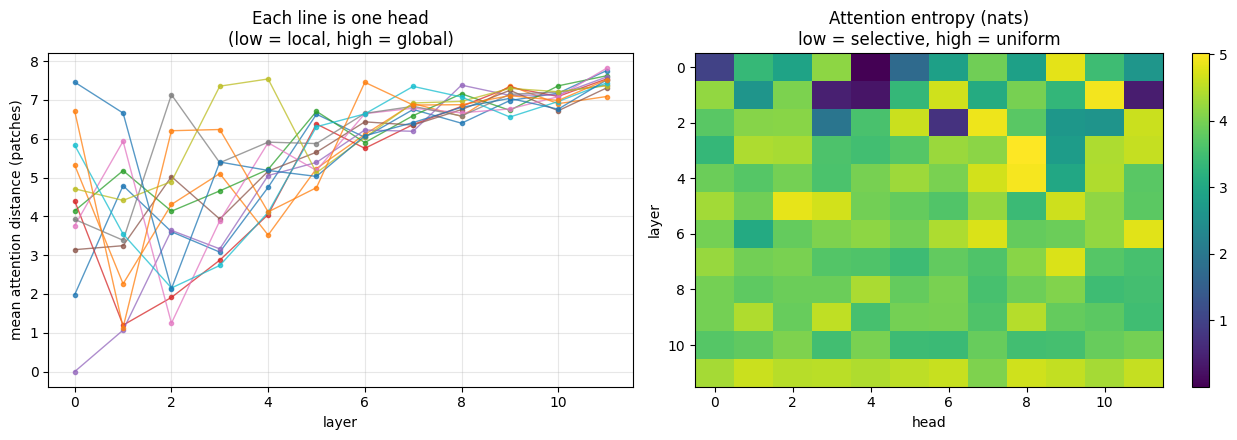

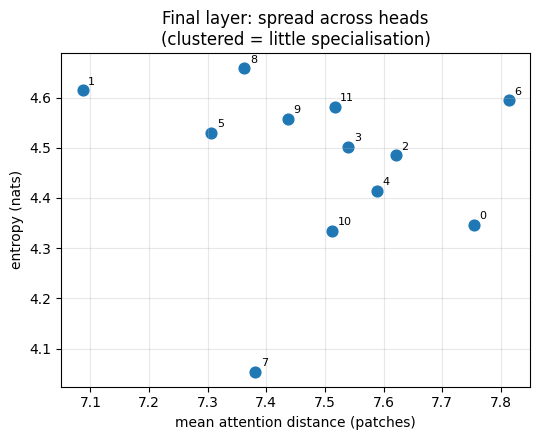

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for h in range(H):
    axes[0].plot(range(L), mad[:, h], marker="o", ms=3, lw=1, alpha=0.75)
axes[0].set_xlabel("layer"); axes[0].set_ylabel("mean attention distance (patches)")
axes[0].set_title("Each line is one head\n(low = local, high = global)")
axes[0].grid(alpha=0.3)

im = axes[1].imshow(ent, aspect="auto", cmap="viridis")
axes[1].set_xlabel("head"); axes[1].set_ylabel("layer")
axes[1].set_title("Attention entropy (nats)\nlow = selective, high = uniform")
fig.colorbar(im, ax=axes[1])

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "task2_3_head_specialization.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(mad[-1], ent[-1], s=60)
for h in range(H):
    ax.annotate(str(h), (mad[-1, h], ent[-1, h]),
                textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_xlabel("mean attention distance (patches)"); ax.set_ylabel("entropy (nats)")
ax.set_title("Final layer: spread across heads\n(clustered = little specialisation)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "task2_3_final_layer_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

In [15]:
def build_transform(processor):
    size = processor.size.get("height", 224) if isinstance(processor.size, dict) else 224
    return transforms.Compose([
        transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
    ])


def get_datasets(tf):
    if DATASET == "stl10":
        train = torchvision.datasets.STL10(DATA_ROOT, split="train", download=True, transform=tf)
        test  = torchvision.datasets.STL10(DATA_ROOT, split="test",  download=True, transform=tf)
    else:
        train = torchvision.datasets.CIFAR10(DATA_ROOT, train=True,  download=True, transform=tf)
        test  = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=tf)
    return train, test, train.classes


def subsample(ds, n, seed):
    """Random subset with a fixed seed so splits are reproducible."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(ds), size=min(n, len(ds)), replace=False)
    return Subset(ds, idx.tolist())


@torch.no_grad()
def extract(model, loader, tag):
    cls_feats, mean_feats, labels = [], [], []
    for x, y in tqdm(loader, desc=f"extract[{tag}]"):
        h = model(pixel_values=x.to(DEVICE)).last_hidden_state    # (B, 197, 768)
        cls_feats.append(h[:, 0].cpu().numpy())
        mean_feats.append(h[:, 1:].mean(1).cpu().numpy())
        labels.append(y.numpy())
    return (np.concatenate(cls_feats), np.concatenate(mean_feats), np.concatenate(labels))

In [16]:
FEATURE_PATH = os.path.join(CACHE_DIR, f"features_{DATASET}.npz")

if os.path.exists(FEATURE_PATH):
    print(f"cache hit -> {FEATURE_PATH}  (delete it to re-extract)")
else:
    backbone = load_backbone()
    tf = build_transform(processor)
    train_full, test_full, classes = get_datasets(tf)

    train = subsample(train_full, N_TRAIN, SEED)
    test  = subsample(test_full,  N_TEST,  SEED + 1)

    # num_workers=0 on Windows avoids the spawn/import headache
    workers = 0 if os.name == "nt" else 2
    train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=False, num_workers=workers)
    test_loader  = DataLoader(test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=workers)

    t0 = time.time()
    tr_cls, tr_mean, tr_y = extract(backbone, train_loader, "train")
    te_cls, te_mean, te_y = extract(backbone, test_loader,  "test")
    print(f"[timing] total extraction: {time.time()-t0:.1f}s")

    np.savez_compressed(
        FEATURE_PATH,
        train_cls=tr_cls, train_mean=tr_mean, train_y=tr_y,
        test_cls=te_cls,  test_mean=te_mean,  test_y=te_y,
        classes=np.array(classes),
    )
    print(f"feature dim: {tr_cls.shape[1]}   train {tr_cls.shape}   test {te_cls.shape}")
    print(f"saved -> {FEATURE_PATH}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 170M/170M [20:45<00:00, 137kB/s]


extract[train]:   0%|          | 0/79 [00:00<?, ?it/s]

extract[test]:   0%|          | 0/32 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de946112160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7de946112160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

[timing] total extraction: 105.5s
feature dim: 768   train (5000, 768)   test (2000, 768)
saved -> /content/cache/features_cifar10.npz


# Task 2.5:

In [17]:
d = np.load(FEATURE_PATH, allow_pickle=True)
classes = [str(c) for c in d["classes"]]
ytr, yte = d["train_y"], d["test_y"]

def l2n(x):
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), 1e-8, None)

variants = {
    "CLS (raw)":          (d["train_cls"],       d["test_cls"]),
    "CLS (L2-norm)":      (l2n(d["train_cls"]),  l2n(d["test_cls"])),
    "MeanPool (raw)":     (d["train_mean"],      d["test_mean"]),
    "MeanPool (L2-norm)": (l2n(d["train_mean"]), l2n(d["test_mean"])),
}
C_GRID = [0.01, 0.1, 1.0, 10.0]


def fit_probe(Xtr, ytr, Xte, yte, C):
    clf = LogisticRegression(C=C, max_iter=2000, n_jobs=-1)
    clf.fit(Xtr, ytr)
    return accuracy_score(yte, clf.predict(Xte)), clf


results, best_models = {}, {}
for name, (Xtr, Xte) in variants.items():
    accs = []
    for C in C_GRID:
        acc, _ = fit_probe(Xtr, ytr, Xte, yte, C)
        accs.append(acc)
        print(f"  {name:<20s} C={C:<6g} test acc = {acc:.4f}")
    results[name] = accs
    bi = int(np.argmax(accs))
    best_models[name] = (C_GRID[bi], accs[bi])
    print(f"  {name:<20s} best  -> C={C_GRID[bi]}, acc={accs[bi]:.4f}\n")

print("Summary (best C per variant):")
for name, (C, acc) in best_models.items():
    print(f"  {name:<20s} {acc:.4f}   (C={C})")

print("\nFeature norm statistics (train split):")
for key, label in [("train_cls", "CLS"), ("train_mean", "MeanPool")]:
    n = np.linalg.norm(d[key], axis=1)
    print(f"  {label:<10s} mean={n.mean():8.3f}  std={n.std():7.3f}")

  CLS (raw)            C=0.01   test acc = 0.9635
  CLS (raw)            C=0.1    test acc = 0.9610
  CLS (raw)            C=1      test acc = 0.9620
  CLS (raw)            C=10     test acc = 0.9635
  CLS (raw)            best  -> C=0.01, acc=0.9635

  CLS (L2-norm)        C=0.01   test acc = 0.9510
  CLS (L2-norm)        C=0.1    test acc = 0.9575
  CLS (L2-norm)        C=1      test acc = 0.9625
  CLS (L2-norm)        C=10     test acc = 0.9630
  CLS (L2-norm)        best  -> C=10.0, acc=0.9630

  MeanPool (raw)       C=0.01   test acc = 0.9680
  MeanPool (raw)       C=0.1    test acc = 0.9680
  MeanPool (raw)       C=1      test acc = 0.9675
  MeanPool (raw)       C=10     test acc = 0.9650
  MeanPool (raw)       best  -> C=0.01, acc=0.9680

  MeanPool (L2-norm)   C=0.01   test acc = 0.9575
  MeanPool (L2-norm)   C=0.1    test acc = 0.9630
  MeanPool (L2-norm)   C=1      test acc = 0.9680
  MeanPool (L2-norm)   C=10     test acc = 0.9675
  MeanPool (L2-norm)   best  -> C=1.0, acc=0

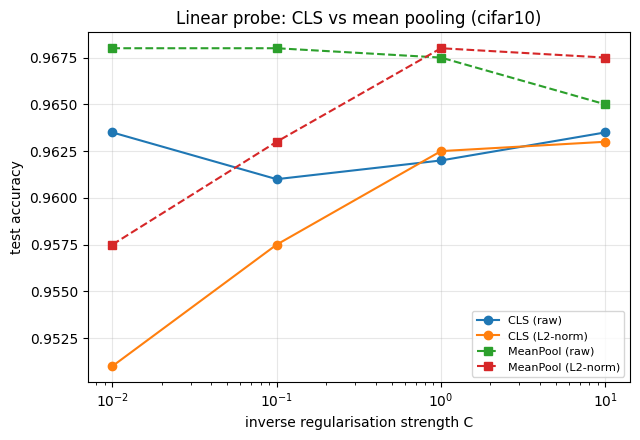

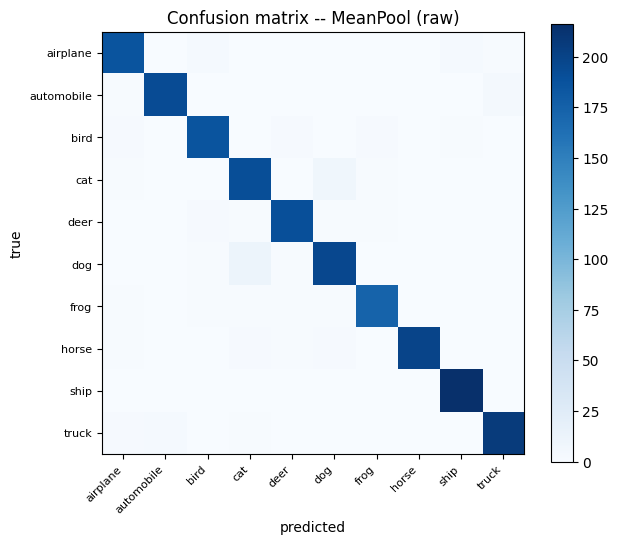

saved -> outputs/task2_5_results.json


In [18]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, accs in results.items():
    ax.plot(C_GRID, accs, "-o" if name.startswith("CLS") else "--s", label=name)
ax.set_xscale("log")
ax.set_xlabel("inverse regularisation strength C"); ax.set_ylabel("test accuracy")
ax.set_title(f"Linear probe: CLS vs mean pooling ({DATASET})")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "task2_5_cls_vs_meanpool.png"), dpi=150, bbox_inches="tight")
plt.show()

best_name = max(best_models, key=lambda k: best_models[k][1])
Xtr, Xte = variants[best_name]
_, clf = fit_probe(Xtr, ytr, Xte, yte, best_models[best_name][0])
cm = confusion_matrix(yte, clf.predict(Xte))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Confusion matrix -- {best_name}")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "task2_5_confusion.png"), dpi=150, bbox_inches="tight")
plt.show()

with open(os.path.join(OUT_DIR, "task2_5_results.json"), "w") as f:
    json.dump({"C_grid": C_GRID, "accuracies": results,
               "best": {k: {"C": v[0], "acc": v[1]} for k, v in best_models.items()}},
              f, indent=2)
print("saved -> outputs/task2_5_results.json")

Task 2.4:

In [19]:
RATIOS = [0.0, 0.1, 0.25, 0.5, 0.75]

backbone = load_backbone()
rng = np.random.default_rng(SEED)

# Probe fitted on CLEAN features only
Xtr_clean = l2n(d["train_cls"])
probe = LogisticRegression(C=1.0, max_iter=2000, n_jobs=-1).fit(Xtr_clean, ytr)

# Same seed as the section-5 test subsample, so we evaluate the same images
tf = build_transform(processor)
if DATASET == "stl10":
    eval_full = torchvision.datasets.STL10(DATA_ROOT, split="test", download=True, transform=tf)
else:
    eval_full = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=tf)

_rng = np.random.default_rng(SEED + 1)
_idx = _rng.choice(len(eval_full), size=min(N_EVAL, len(eval_full)), replace=False)
workers = 0 if os.name == "nt" else 2
eval_loader = DataLoader(Subset(eval_full, _idx.tolist()),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=workers)


@torch.no_grad()
def masked_accuracy(backbone, loader, clf, grid, strategy, ratio, rng):
    n_mask = int(round(ratio * grid * grid))
    correct = total = 0
    for x, y in loader:
        x = x.to(DEVICE)
        if n_mask > 0:
            if strategy == "random":
                idx = random_patch_indices(n_mask, grid, rng)   # fresh mask per batch
            elif strategy == "center":
                idx = center_patch_indices(n_mask, grid)
            else:
                idx = border_patch_indices(n_mask, grid)
            x = mask_patches(x, idx, grid)

        h = backbone(pixel_values=x).last_hidden_state[:, 0].cpu().numpy()
        correct += (clf.predict(l2n(h)) == y.numpy()).sum()
        total += len(y)
    return correct / total

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


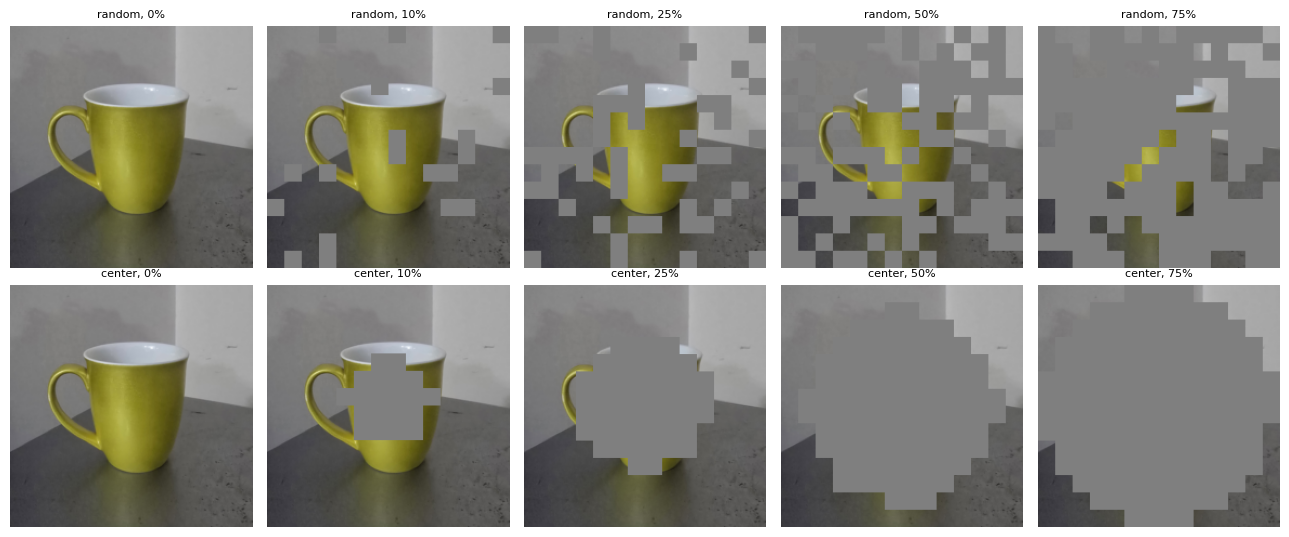

In [20]:
_img = Image.open(image_paths[0]).convert("RGB")
_pv = processor(images=_img, return_tensors="pt")["pixel_values"]
_rng2 = np.random.default_rng(SEED)

cols = len(RATIOS)
fig, axes = plt.subplots(2, cols, figsize=(2.6*cols, 5.4))
for j, ratio in enumerate(RATIOS):
    n_mask = int(round(ratio * GRID * GRID))
    for i, strategy in enumerate(("random", "center")):
        if n_mask == 0:
            x = _pv
        else:
            idx = (random_patch_indices(n_mask, GRID, _rng2) if strategy == "random"
                   else center_patch_indices(n_mask, GRID))
            x = mask_patches(_pv, idx, GRID)
        axes[i, j].imshow(denormalize(x, processor)[0].permute(1, 2, 0).numpy())
        axes[i, j].set_title(f"{strategy}, {ratio:.0%}", fontsize=8)
        axes[i, j].axis("off")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "task2_4_mask_examples.png"), dpi=150, bbox_inches="tight")
plt.show()

In [21]:
strategies = ["random", "center", "border"]
mask_results = {s: [] for s in strategies}

print(f"about {len(RATIOS)*len(strategies)*N_EVAL} forward passes -- "
      f"expect a few minutes on CPU\n")

t0 = time.time()
for strategy in strategies:
    for ratio in tqdm(RATIOS, desc=f"{strategy:<7s}"):
        mask_results[strategy].append(
            masked_accuracy(backbone, eval_loader, probe, GRID, strategy, ratio, rng))
print(f"[timing] part A total: {time.time()-t0:.1f}s")

print("\nratio |  random  |  center  |  border")
for i, r in enumerate(RATIOS):
    print(f" {r:>4.0%} |  {mask_results['random'][i]:.4f}  |  "
          f"{mask_results['center'][i]:.4f}  |  {mask_results['border'][i]:.4f}")

np.savez(os.path.join(OUT_DIR, "task2_4_masking_results.npz"),
         ratios=np.array(RATIOS), **{k: np.array(v) for k, v in mask_results.items()})

about 15000 forward passes -- expect a few minutes on CPU



random :   0%|          | 0/5 [00:00<?, ?it/s]

center :   0%|          | 0/5 [00:00<?, ?it/s]

border :   0%|          | 0/5 [00:00<?, ?it/s]

[timing] part A total: 226.4s

ratio |  random  |  center  |  border
   0% |  0.9660  |  0.9660  |  0.9660
  10% |  0.9590  |  0.9150  |  0.9710
  25% |  0.9250  |  0.7800  |  0.9680
  50% |  0.7820  |  0.5860  |  0.9370
  75% |  0.4380  |  0.4330  |  0.6910


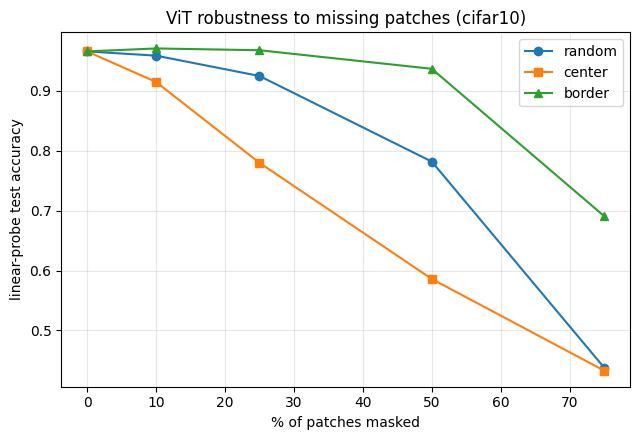

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for strategy, marker in zip(strategies, ["o", "s", "^"]):
    ax.plot([r*100 for r in RATIOS], mask_results[strategy], marker=marker, label=strategy)
ax.set_xlabel("% of patches masked"); ax.set_ylabel("linear-probe test accuracy")
ax.set_title(f"ViT robustness to missing patches ({DATASET})")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "task2_4_masking_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [23]:
@torch.no_grad()
def stability_report():
    for path in image_paths:
        stem = os.path.basename(path)
        image = Image.open(path).convert("RGB")
        pv = processor(images=image, return_tensors="pt")["pixel_values"].to(DEVICE)

        clean_logits = classifier(pixel_values=pv).logits
        clean_idx = int(clean_logits.argmax(-1))
        clean_label = classifier.config.id2label[clean_idx]
        clean_p = float(clean_logits.softmax(-1)[0, clean_idx])
        print(f"\n  {stem}: clean = {clean_label} ({clean_p:.3f})")

        for strategy in ("random", "center"):
            row = []
            for ratio in RATIOS[1:]:
                n_mask = int(round(ratio * GRID * GRID))
                idx = (random_patch_indices(n_mask, GRID, rng) if strategy == "random"
                       else center_patch_indices(n_mask, GRID))
                probs = classifier(pixel_values=mask_patches(pv, idx, GRID)).logits.softmax(-1)[0]
                kept = "same" if int(probs.argmax()) == clean_idx else "CHANGED"
                row.append(f"{ratio:.0%}: p={float(probs[clean_idx]):.3f} [{kept}]")
            print(f"    {strategy:<7s} " + "  ".join(row))

print("Top-1 stability under masking (ImageNet head):")
stability_report()

Top-1 stability under masking (ImageNet head):

  1000311708.jpg: clean = coffee mug (0.615)
    random  10%: p=0.755 [same]  25%: p=0.639 [same]  50%: p=0.773 [same]  75%: p=0.026 [CHANGED]
    center  10%: p=0.473 [CHANGED]  25%: p=0.029 [CHANGED]  50%: p=0.009 [CHANGED]  75%: p=0.003 [CHANGED]

  5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49276.jpg: clean = wall clock (0.835)
    random  10%: p=0.747 [same]  25%: p=0.697 [same]  50%: p=0.720 [same]  75%: p=0.102 [CHANGED]
    center  10%: p=0.001 [CHANGED]  25%: p=0.002 [CHANGED]  50%: p=0.008 [CHANGED]  75%: p=0.009 [CHANGED]

  5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49279.jpg: clean = running shoe (0.883)
    random  10%: p=0.879 [same]  25%: p=0.885 [same]  50%: p=0.043 [CHANGED]  75%: p=0.047 [CHANGED]
    center  10%: p=0.181 [CHANGED]  25%: p=0.000 [CHANGED]  50%: p=0.000 [CHANGED]  75%: p=0.000 [CHANGED]


In [25]:
produced = sorted(os.listdir(OUT_DIR))
print(f"{len(produced)} file(s) in outputs/:")
for f in produced:
    print("  -", f)

if IN_COLAB:
    import shutil
    from google.colab import files
    shutil.make_archive("task2_outputs", "zip", OUT_DIR)
    files.download("task2_outputs.zip")

    # Optional: also save the executed notebook + figures to Drive so nothing is
    # lost on disconnect. Uncomment to use.
    from google.colab import drive
    drive.mount("/content/drive")
    shutil.copytree(OUT_DIR, "/content/drive/MyDrive/atml_task2_outputs",
                    dirs_exist_ok=True)

16 file(s) in outputs/:
  - task2_1_predictions.json
  - task2_2_attention_1000311708.png
  - task2_2_attention_5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49276.png
  - task2_2_attention_5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49279.png
  - task2_3_final_layer_scatter.png
  - task2_3_head_specialization.png
  - task2_3_head_stats.npz
  - task2_3_heads_1000311708.png
  - task2_3_heads_5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49276.png
  - task2_3_heads_5f4f2cfd-db33-480a-aa74-26e7bb0a099c-1_all_49279.png
  - task2_4_mask_examples.png
  - task2_4_masking_curves.png
  - task2_4_masking_results.npz
  - task2_5_cls_vs_meanpool.png
  - task2_5_confusion.png
  - task2_5_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Mounted at /content/drive
